<a href="https://colab.research.google.com/github/tylerjohnbecker/Nonlinear_and_Data_Driven_Estimation/blob/main/BouncingBallAIUKF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [276]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import keras
from collections import deque
from scipy.integrate import odeint

In [277]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

In [278]:

try:
    import casadi as ca
except:
    !pip install casadi
    import casadi as ca

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

# Dynamics

In [279]:
g = -9.8
m = 1
r = .5
e = .3
mu = .6
x0 = np.array([0, 0, 3, 0, 0, 4, m, e, mu])
Im = 0.4 * m * r ** 2

In [280]:
def estimate_damping_from_cor(e, m, stiffness):

    # Calculate damping ratio from coefficient of restitution
    ln_e = np.log(e)

    e = max(e, 1e-4)
    m = max(m, 1e-4)
    stiffness = max(stiffness, 1e-4)

    xi = np.sqrt(ln_e**2 / (np.pi**2 + ln_e**2))

    # For very low e, increase damping further
    correction = 1.0 + (0.3 - e) * 2.0

    xi = ca.if_else(e < .3, xi, xi * correction);

    # Calculate critical damping
    damping = 2 * xi * np.sqrt(m * stiffness)

    damping = ca.if_else(ca.fabs(e - 1.0) < 1e-6, 0.0, damping);

    return np.array([damping]).flatten()[0]

In [281]:
def sigm_transition( z, r, width=.05):
    center = r + width
    return 1 / (1 + np.exp(-(z - center) / width))

In [282]:
def f_in_air(x_vec, u_vec, g, r, Im):

    # Extract state variables
    x = x_vec[0]
    x_dot = x_vec[1]
    z = x_vec[2]
    z_dot = x_vec[3]
    theta = x_vec[4]
    theta_dot = x_vec[5]

    m = x_vec[6]
    e = x_vec[7]
    mu = x_vec[8]

    # Extract control inputs
    f_x = u_vec[0]
    f_z = u_vec[1]
    tor = u_vec[2]

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ x_dot,
                                 0,
                                 z_dot,
                                 g,
                                 theta_dot,
                                 0,
                                 0,
                                 0,
                                 0])

    # f1 component: multiplied by control u1
    f_other_contribution = np.array([0,
                                     f_x / m,
                                     0,
                                     f_z / m,
                                     0,
                                     tor / Im,
                                     0,
                                     0,
                                     0])

    x_dot_vec = f0_contribution + f_other_contribution

    return x_dot_vec

In [283]:
def f_impact(x_vec, u_vec, g, r, Im, stiffness, damping):
    x_dot = x_vec[1]
    z_dot = x_vec[3]
    theta_dot = x_vec[5]
    z = x_vec[2]

    m = x_vec[6]
    e = x_vec[7]
    mu = x_vec[8]

    f_x, f_z, tau = u_vec[0], u_vec[1], u_vec[2]

    # Penetration depth (positive when in contact)
    penetration = r - z

    # Normal force (Hunt-Crossley contact model)
    f_normal = stiffness * penetration - damping * penetration * z_dot
    f_normal = np.array([ca.if_else(f_normal > 0, f_normal, 0)]).flatten()[0]
    f_normal = np.array([ca.if_else(penetration > 0, f_normal, 0)]).flatten()[0]

    # Tangential velocity at contact point (bottom of ball)
    v_contact = x_dot - r * theta_dot

    # Friction force opposes contact point motion
    v_threshold = 0.1  # m/s - smoothing parameter
    friction_direction = np.tanh(v_contact / v_threshold)
    f_friction_ideal = -mu * f_normal * friction_direction

    # Cap friction force to prevent unrealistic accelerations
    max_friction_force = 1.0  # Newtons - tune based on your ball mass

    friction_sign = np.sign(f_friction_ideal)
    f_friction_ideal = friction_sign * f_friction_ideal

    f_friction = np.array([ca.if_else(f_friction_ideal > max_friction_force, max_friction_force, f_friction_ideal)]).flatten()[0] * friction_sign

    # Equations of motion
    x_dot_vec = np.array([
        x_dot,
        (f_x + f_friction) / m,
        z_dot,
        -g + (f_z + f_normal) / m,
        theta_dot,
        (tau - r * f_friction) / Im,
        0,
        0,
        0
    ])

    return x_dot_vec

In [284]:
def f_combined(x_vec, u_vec, g=g, Im=Im, r=r, m=m, e=e, mu=mu, stiffness=100, transition_width=0.01):
    """
    Combined dynamics with smooth transition.
    """
    alpha = sigm_transition(x_vec[2], r, transition_width)

    f_air = f_in_air(x_vec, u_vec, g, r, Im)
    f_cont = f_impact(x_vec, u_vec, g, r, Im, stiffness, estimate_damping_from_cor(x_vec[7], x_vec[6], stiffness))

    return alpha * f_air + (1 - alpha) * f_cont

In [285]:
def f_ode(x_vec, tsim, u_func, f):
    u_vec = u_func(x_vec, tsim)
    x_dot_vec = f(x_vec, u_vec)

    return x_dot_vec

# Measurements

In [286]:
measurement_noise_stds = {
    'x': 0.2,
    'z': 0.2,
    'theta_dot': 0.1,
    'mu': .04
}

In [287]:
def h_xyt(x_vec, u_vec):
    return np.array([x_vec[0], x_vec[2], x_vec[5]])

In [288]:
def h_plus_NN(x_vec, u_vec):
    return np.array([x_vec[0], x_vec[2], x_vec[5], x_vec[8]])

In [289]:
def add_noise_to_measurements(measurements):
    for i in range(len(measurements)):
        measurements[i][0] += np.random.normal(0, measurement_noise_stds['x'])
        measurements[i][1] += np.random.normal(0, measurement_noise_stds['z'])
        measurements[i][2] += np.random.normal(0, measurement_noise_stds['theta_dot'])

# Load AI Model

In [290]:
def confidence_weighted_loss(y_true, y_pred):
    """
    Weighted loss that uses confidence labels

    y_true: [mu_true, e_true, conf_mu_true, conf_e_true]
    y_pred: [mu_pred, e_pred, conf_mu_pred, conf_e_pred]
    """
    # Extract components
    mu_true = y_true[:, 0]
    e_true = y_true[:, 1]
    conf_mu_true = y_true[:, 2]
    conf_e_true = y_true[:, 3]

    mu_pred = y_pred[:, 0]
    e_pred = y_pred[:, 1]
    conf_mu_pred = y_pred[:, 2]
    conf_e_pred = y_pred[:, 3]

    # Confidence-weighted parameter losses
    mu_loss = conf_mu_true * tf.square(mu_pred - mu_true)
    e_loss = conf_e_true * tf.square(e_pred - e_true)

    # Confidence prediction losses
    conf_mu_loss = tf.square(conf_mu_pred - conf_mu_true)
    conf_e_loss = tf.square(conf_e_pred - conf_e_true)

    # Calibration loss (penalize overconfident wrong predictions)
    mu_error = tf.abs(mu_pred - mu_true)
    e_error = tf.abs(e_pred - e_true)
    calibration_mu = conf_mu_pred * mu_error
    calibration_e = conf_e_pred * e_error

    # Combine
    total_loss = (
        tf.reduce_mean(mu_loss) +
        tf.reduce_mean(e_loss) +
        0.3 * tf.reduce_mean(conf_mu_loss) +
        0.3 * tf.reduce_mean(conf_e_loss) +
        0.2 * tf.reduce_mean(calibration_mu) +
        0.2 * tf.reduce_mean(calibration_e)
    )

    return total_loss

In [291]:
model = None

with tf.keras.utils.custom_object_scope({'confidence_weighted_loss': confidence_weighted_loss}):
    model = tf.keras.models.load_model('friction_model.h5')

# Integrated AI UKF Setup

In [311]:
class NNWindowManager:
    def __init__(self, window_size=10, nn_model=None, dt=0.05):
        self.window_size = window_size
        self.nn_model = nn_model
        self.observation_buffer = []

        self.dt = dt

    def add_observation(self, x, z, theta_dot, fx, fz, tau):
        """Add one timestep of observations"""
        if len(self.observation_buffer) > 0:
            prev_x = self.observation_buffer[-1][0]
            prev_z = self.observation_buffer[-1][1]
        else:
            prev_x = x
            prev_z = z

        x_dot = (x - prev_x) / self.dt
        z_dot = (z - prev_z) / self.dt

        obs = [x, z, theta_dot, x_dot, z_dot, fx, fz, tau]
        self.observation_buffer.append(obs)

        if len(self.observation_buffer) > self.window_size:
            del self.observation_buffer[0]

    def is_ready(self):
        """Check if we have enough observations"""
        return len(self.observation_buffer) == self.window_size

    def get_nn_input(self, radius, mu_prior, e_prior):
        """Construct input vector for NN"""
        if not self.is_ready():
            return None

        # Flatten: [radius, mu_prior, e_prior, obs_0, obs_1, ..., obs_9]
        input_vec = [radius, mu_prior, e_prior]
        for obs in self.observation_buffer:
            input_vec.extend(obs)

        return np.array(input_vec).reshape(1, -1)

    def predict(self, radius, mu_prior, e_prior):
        """Get NN prediction with confidence"""
        nn_input = self.get_nn_input(radius, mu_prior, e_prior)

        if nn_input is None:
            return {
                'mu': mu_prior,
                'e': e_prior,
                'conf_mu': .4,
                'conf_e': .4
            }

        # Predict: [mu, e, conf_mu, conf_e]
        prediction = self.nn_model.predict(nn_input, verbose=0)[0]

        return {
            'mu': prediction[0],
            'e': prediction[1],
            'conf_mu': prediction[2],
            'conf_e': prediction[3]
        }

# Evaluation

## Generate Trajectory

In [773]:
class BouncingBallController:
    """
    Controller to make the ball bounce back and forth.

    Strategy:
    - When above 1m: apply forces to move horizontally and maintain height
    - When below 1m: no control (let natural dynamics/friction work)
    - Oscillate between left and right targets
    """

    def __init__(self,
                 target_bounce_height=1.5,  # Desired peak height (m)
                 target_x_amplitude=2.0,     # How far left/right (m)
                 oscillation_period=3.0,     # Time for full cycle (s)
                 control_threshold=1.0,      # No control below this (m)
                 push_down_height=1.3,       # Start pushing down at this height (m)
                 m=0.5,
                 g=9.81,
                 Im=0.002,
                 r=0.1):

        self.target_bounce_height = target_bounce_height
        self.target_x_amplitude = target_x_amplitude
        self.oscillation_period = oscillation_period
        self.control_threshold = control_threshold
        self.push_down_height = push_down_height
        self.m = m
        self.g = g
        self.Im = Im
        self.r = r

        # Horizontal control gains
        self.K_p_x = 25.0
        self.K_d_x = 15.0

        # Rotation control gains (keep upright)
        self.K_p_theta = 10.0
        self.K_d_theta = 5.0

        # Downward push force
        self.push_force = 6.0  # Additional downward force (N)

        # Control limits
        self.max_f_x = 50.0
        self.max_f_z = 100.0
        self.max_tau = 5.0

        # State tracking
        self.last_z = None
        self.last_z_dot = None

    def get_target_x(self, t):
        """
        Get desired horizontal position as function of time.
        Oscillates sinusoidally between -amplitude and +amplitude.
        """
        omega = 2 * np.pi / self.oscillation_period
        return self.target_x_amplitude * np.sin(omega * t)

    def get_target_x_dot(self, t):
        """
        Get desired horizontal velocity (derivative of target position).
        """
        omega = 2 * np.pi / self.oscillation_period
        return self.target_x_amplitude * omega * np.cos(omega * t)

    def __call__(self, x_vec, t):
        """
        Compute control inputs based on current state.

        Parameters:
        -----------
        t : float
            Current time (s)
        x_vec : array, shape (6,)
            State vector [x, ẋ, z, ż, θ, θ̇]

        Returns:
        --------
        u : array, shape (3,)
            Control vector [f_x, f_z, τ]
        """
        x = x_vec[0]
        x_dot = x_vec[1]
        z = x_vec[2]
        z_dot = x_vec[3]
        theta = x_vec[4]
        theta_dot = x_vec[5]

        # Below control threshold: no control
        if z < self.control_threshold:
            self.last_z = z
            self.last_z_dot = z_dot
            return np.array([0.0, 0.0, 0.0])

        # --- Horizontal Control ---
        x_desired = self.get_target_x(t)
        x_dot_desired = self.get_target_x_dot(t)

        x_error = x_desired - x
        x_dot_error = x_dot_desired - x_dot

        f_x = self.K_p_x * x_error + self.K_d_x * x_dot_error

        # --- Vertical Control ---
        # Strategy: push down when high, let bounce happen naturally

        if z_dot > 0:
            # Ball is rising - let it rise naturally (no force)
            f_z = 0.0
        elif z > self.push_down_height:
            # Ball is high and falling - push it down harder
            f_z = -self.push_force  # Negative = downward
        else:
            # Ball is lower - let gravity do the work
            f_z = 0.0

        # --- Rotation Control ---
        theta_error = 0.0 - theta
        theta_dot_error = 0.0 - theta_dot

        tau = self.K_p_theta * theta_error + self.K_d_theta * theta_dot_error

        # --- Apply Limits ---
        f_x = np.clip(f_x, -self.max_f_x, self.max_f_x)
        f_z = np.clip(f_z, -self.max_f_z, self.max_f_z)
        tau = np.clip(tau, -self.max_tau, self.max_tau)

        self.last_z = z
        self.last_z_dot = z_dot

        return np.array([f_x, f_z, tau])

In [774]:
def go_right_controller(x_vec, t):

    to_ret = np.array([0.0, 0.0, 0.0])

    x_err = 30 - x_vec[1]

    z_err = -20 - x_vec[3]

    theta_err = 6.28 - x_vec[5]

    to_ret += np.array([x_err, 0, 0])

    if x_vec[3] < 0 and z_err < 0:
        to_ret += np.array([0, z_err, 0])

    if x_vec[5] > 6.28:
        to_ret += np.array([0, 0, theta_err])

    return to_ret

In [775]:
delta_t = 0.005
max_time = 10

tsim = np.arange(0, max_time, delta_t)

In [776]:
x0 = np.array([0, 1, 20.0, 0, 0, 0, m, e, mu])

left_right_controller = BouncingBallController()
result = odeint(f_ode, x0, tsim, args=(go_right_controller, f_combined) )

In [777]:
# this might be an unecessary fix but I was getting index out of bounds for no reason
cur_time = delta_t
u_np = []
left_right_controller = BouncingBallController()

while cur_time <= max_time:
    index = len(u_np)

    u_t = go_right_controller(result[index], cur_time)
    u_np.append(u_t)
    cur_time += delta_t

u_np = np.array(u_np)

Text(0, 0.5, 'z')

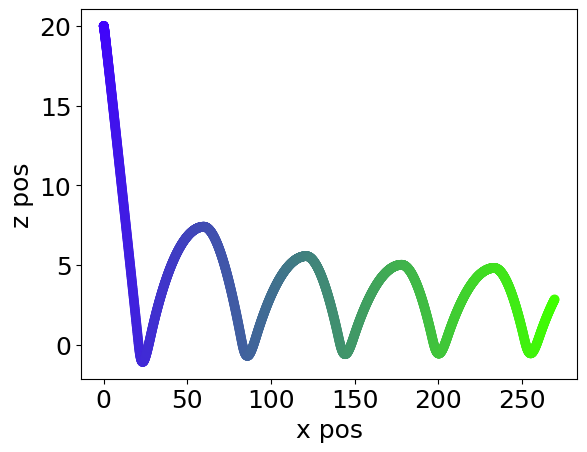

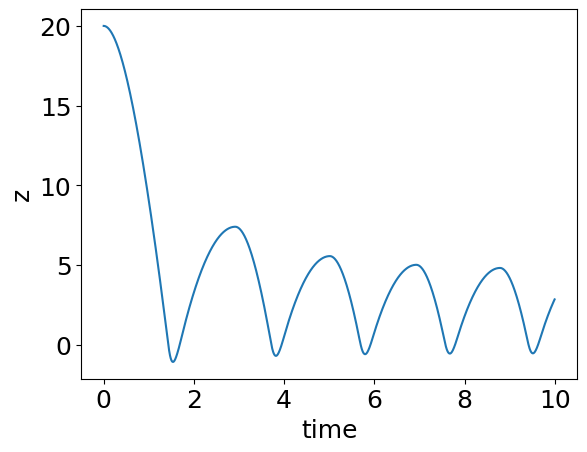

In [778]:
fig = plt.figure()

num = len(result[:, 0])
colors = [ (.25 , i / num , 1 - i / num ) for i in range(num) ]

ax = fig.add_subplot(111)
ax.scatter(result[:, 0], result[:, 2], c=colors)
ax.set_xlabel('x pos')
ax.set_ylabel('z pos')

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
ax1.plot(tsim, result[:,2])
ax1.set_xlabel('time')
ax1.set_ylabel('z')

In [779]:
x_sim_df = pd.DataFrame(result, columns=['x', 'x_dot', 'z', 'z_dot', 'theta', 'theta_dot', 'm', 'e', 'mu'])
u_sim_df = pd.DataFrame(u_np, columns=['f_x', 'f_z', 'tau'])

## Generate Results for UKF

In [792]:
# generate measurements without 'mu'
y = x_sim_df[['x', 'z', 'theta_dot']].to_numpy()
y_noisy = y.copy()
add_noise_to_measurements(y_noisy)

y_df = pd.DataFrame(y, columns=['x', 'z', 'theta_dot'])
y_noisy_df = pd.DataFrame(y_noisy, columns=['x', 'z', 'theta_dot'])

<Axes: xlabel='Time', ylabel='theta_dot'>

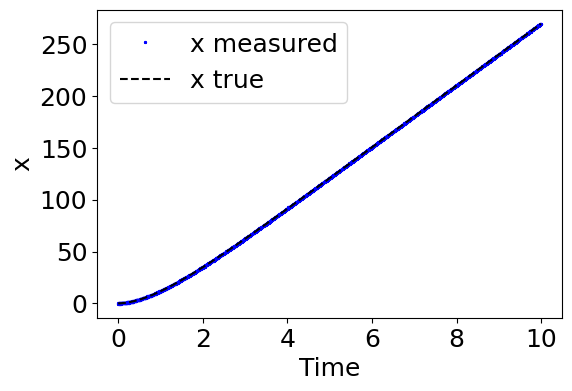

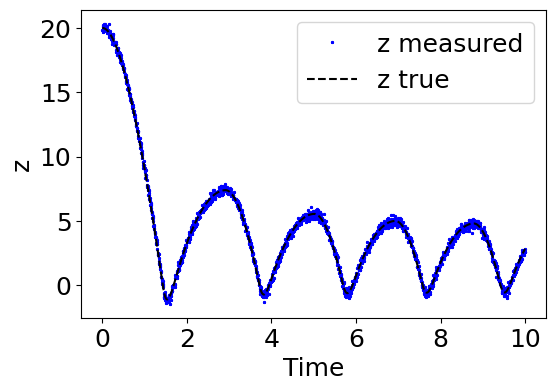

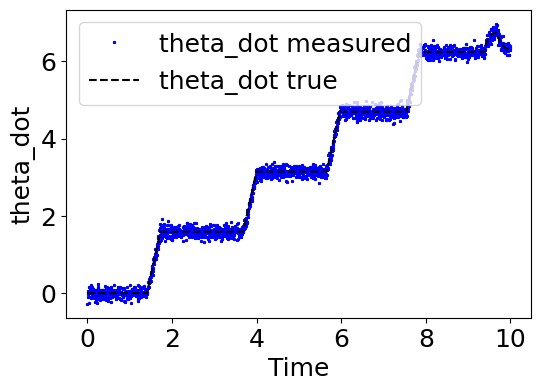

In [793]:
plot_tme(tsim, y_df['x'], y_noisy_df['x'], label_var='x')
plot_tme(tsim, y_df['z'], y_noisy_df['z'], label_var='z')
plot_tme(tsim, y_df['theta_dot'], y_noisy_df['theta_dot'], label_var='theta_dot')

### Starting Conditions

In [794]:
x0 = np.array([0, 0, 3.0, -1, 0, 0, 1.5, .8, .3])
u0 = np.zeros(3)
P0 = np.diag([.1, .2, .1, .5, .1, .5, .0001, .001, .00001])

In [795]:
R = np.diag( [.2, .2, .1] )**2
Q = np.diag([1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 9e-5])

### Estimation

In [796]:
UKF = unscented_kalman_filter.UKF(f_combined, h_xyt, x0, u0, P0, Q, R,
                                 dynamics_type='continuous', discretization_timestep=delta_t,
                                 alpha=.1)

In [797]:
UKF.estimate(y_noisy_df, u_sim_df)

In [798]:
# State estimate
x_est = pd.DataFrame(np.vstack(UKF.history['X']), columns=['x', 'x_dot', 'z', 'z_dot', 'theta', 'theta_dot', 'm', 'e', 'mu'])

In [799]:
# Covariance diagonals
P_diags = np.vstack([np.diag(UKF.history['P'][i]) for i in range(len(UKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=['x', 'x_dot', 'z', 'z_dot', 'theta', 'theta_dot', 'm', 'e', 'mu'])

In [800]:
def plot_state(state, x_sim, x_est):
  fig = plt.figure()
  ax = fig.add_subplot(111)

  plot_tme(tsim, x_sim[state], None, x_est[state], label_var=state, ax=ax)

  plus3sigma = x_est[state] + 3*np.sqrt(P_diags[state])
  minus3sigma = x_est[state] - 3*np.sqrt(P_diags[state])

  ax.fill_between(tsim, plus3sigma, minus3sigma, facecolor='red', edgecolor='none', alpha=0.2)

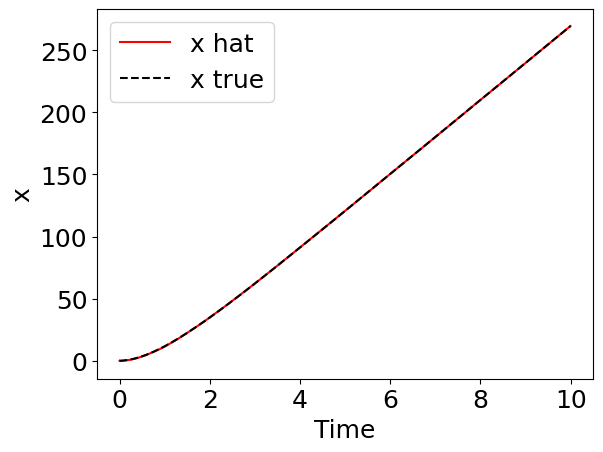

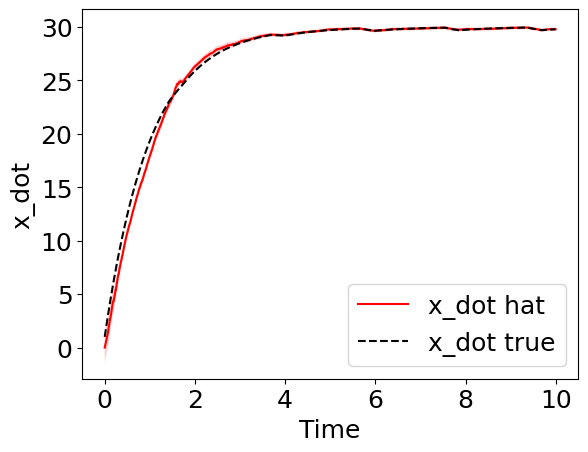

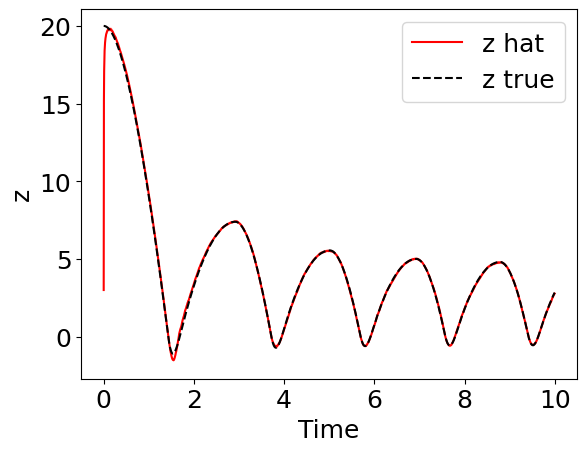

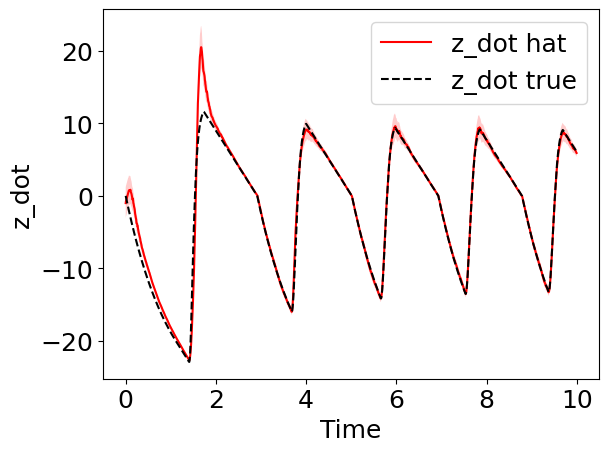

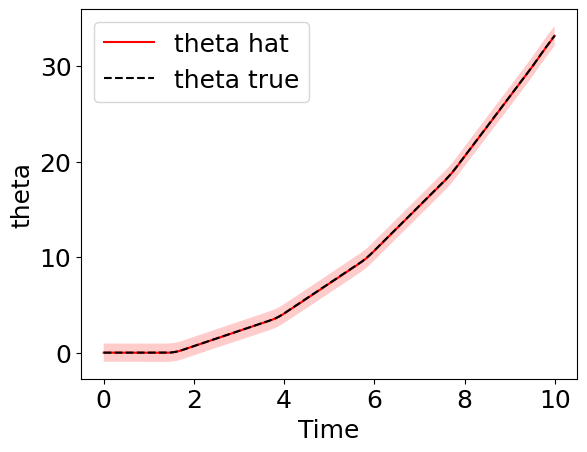

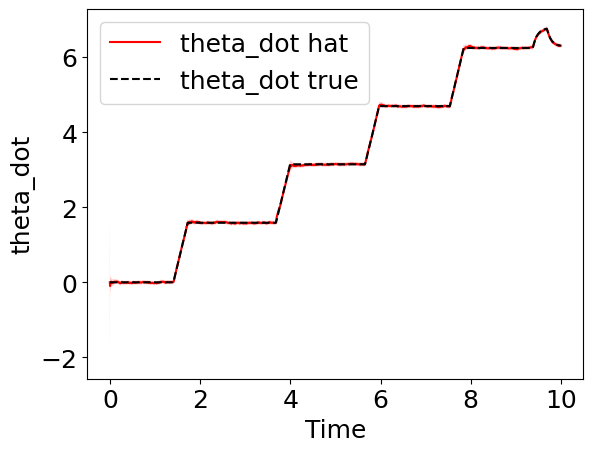

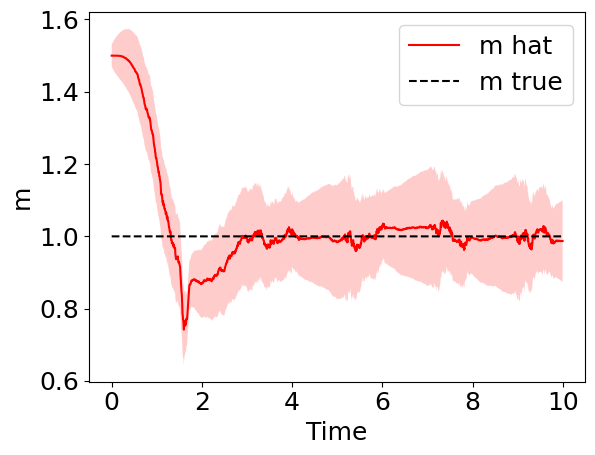

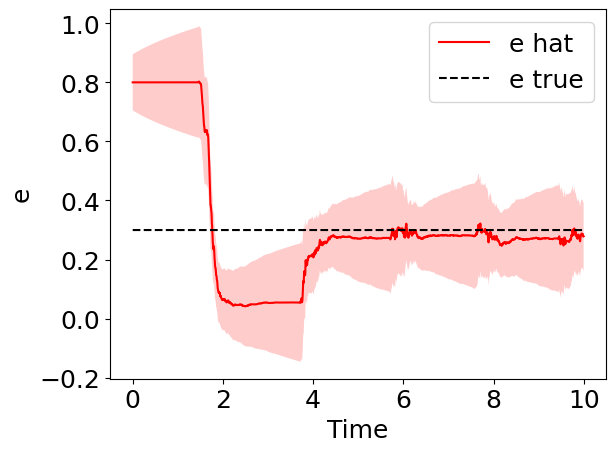

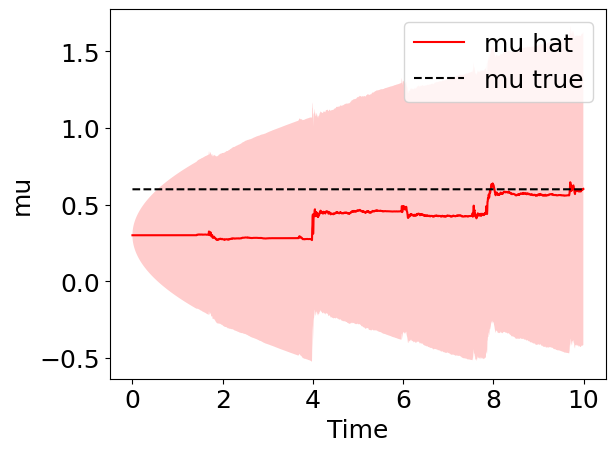

In [801]:
# linear components
plot_state('x', x_sim_df, x_est)
plot_state('x_dot', x_sim_df, x_est)
plot_state('z', x_sim_df, x_est)
plot_state('z_dot', x_sim_df, x_est)
plot_state('theta', x_sim_df, x_est)
plot_state('theta_dot', x_sim_df, x_est)

# nonlinear components
plot_state('m', x_sim_df, x_est)
plot_state('e', x_sim_df, x_est)
plot_state('mu', x_sim_df, x_est)

In [802]:
def compute_mean_error(gt, est, state):
    return np.mean(np.abs(gt[state] - est[state]))

In [803]:
compute_mean_error(x_sim_df, x_est, 'theta_dot')

0.01066899720160777